In [1]:
import sys
import torch
sys.path.insert(0, r"d:\VS codes\ML Coding")

from model.detector import build_detector, get_model_summary
from losses.detection_loss import compute_total_loss, LossTracker, DEFAULT_LOSS_WEIGHTS

device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 7

model = build_detector(NUM_CLASSES, pretrained_backbone=True).to(device)
model.train()

print(f"Device  : {device}")
print(f"Model   : ready")
print(f"Losses  : imported")

[Backbone] Built resnet50 + FPN
[Backbone] Output channels: 256
[Backbone] Pretrained: True
[Backbone] Frozen params: 24 | Trainable params: 45

[Detector] Model built successfully
[Detector] Backbone    : resnet50 + FPN
[Detector] Num classes : 7 (including background)
[Detector] Anchors     : 5 levels x 3 ratios = 15 anchor types
[Detector] ROI output  : 7x7 per proposal

Device  : cpu
Model   : ready
Losses  : imported


In [2]:
# Simulate one training batch
dummy_images = [
    torch.rand(3, 800, 800).to(device),
    torch.rand(3, 600, 800).to(device),
]

dummy_targets = [
    {
        "boxes":    torch.tensor([[50., 30., 200., 250.],
                                  [300., 100., 500., 400.]], device=device),
        "labels":   torch.tensor([1, 3], device=device),
        "image_id": torch.tensor([1],    device=device),
        "area":     torch.tensor([24500., 60000.], device=device),
        "iscrowd":  torch.tensor([0, 0], device=device),
    },
    {
        "boxes":    torch.tensor([[10., 20., 100., 150.]], device=device),
        "labels":   torch.tensor([1],  device=device),
        "image_id": torch.tensor([2],  device=device),
        "area":     torch.tensor([13000.], device=device),
        "iscrowd":  torch.tensor([0],  device=device),
    },
]

with torch.no_grad():
    loss_dict = model(dummy_images, dummy_targets)

print("=== Raw Loss Dict ===\n")
for name, value in loss_dict.items():
    print(f"  {name:<25} : {value.item():.4f}")

=== Raw Loss Dict ===

  loss_classifier           : 1.9214
  loss_box_reg              : 0.0125
  loss_objectness           : 0.6845
  loss_rpn_box_reg          : 0.0062


In [3]:
total_loss = compute_total_loss(loss_dict)

print("=== Total Loss Computation ===\n")
print(f"  Loss weights used:")
for name, weight in DEFAULT_LOSS_WEIGHTS.items():
    val = loss_dict[name].item()
    print(f"    {name:<25} x {weight} = {val * weight:.4f}")

print(f"\n  Total loss : {total_loss.item():.4f}")
print(f"  Type       : {type(total_loss)}")
print(f"  Requires grad: {total_loss.requires_grad}")

=== Total Loss Computation ===

  Loss weights used:
    loss_objectness           x 1.0 = 0.6845
    loss_rpn_box_reg          x 1.0 = 0.0062
    loss_classifier           x 1.0 = 1.9214
    loss_box_reg              x 1.0 = 0.0125

  Total loss : 2.6246
  Type       : <class 'torch.Tensor'>
  Requires grad: False


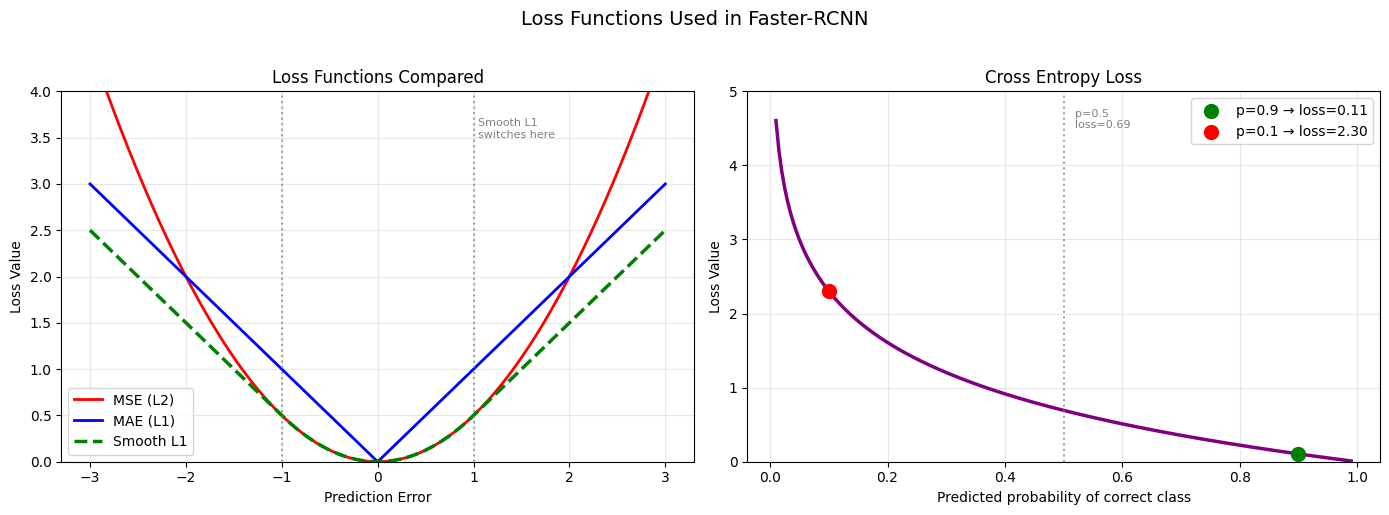

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Show how Smooth L1 compares to MSE and MAE
x = np.linspace(-3, 3, 300)

mse      = 0.5 * x**2
mae      = np.abs(x)
smooth_l1 = np.where(np.abs(x) < 1,
                     0.5 * x**2,
                     np.abs(x) - 0.5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss curves
axes[0].plot(x, mse,       label="MSE (L2)",     color="red",    linewidth=2)
axes[0].plot(x, mae,       label="MAE (L1)",     color="blue",   linewidth=2)
axes[0].plot(x, smooth_l1, label="Smooth L1",    color="green",  linewidth=2.5,
             linestyle="--")
axes[0].set_title("Loss Functions Compared", fontsize=12)
axes[0].set_xlabel("Prediction Error")
axes[0].set_ylabel("Loss Value")
axes[0].legend()
axes[0].set_ylim(0, 4)
axes[0].axvline(x=1,  color="gray", linestyle=":", alpha=0.7)
axes[0].axvline(x=-1, color="gray", linestyle=":", alpha=0.7)
axes[0].text(1.05, 3.5, "Smooth L1\nswitches here", fontsize=8, color="gray")
axes[0].grid(True, alpha=0.3)

# Plot 2: Cross entropy behaviour
probs = np.linspace(0.01, 0.99, 200)
ce    = -np.log(probs)

axes[1].plot(probs, ce, color="purple", linewidth=2.5)
axes[1].set_title("Cross Entropy Loss", fontsize=12)
axes[1].set_xlabel("Predicted probability of correct class")
axes[1].set_ylabel("Loss Value")
axes[1].axvline(x=0.5, color="gray", linestyle=":", alpha=0.7)
axes[1].text(0.52, 4.5, "p=0.5\nloss=0.69", fontsize=8, color="gray")
axes[1].scatter([0.9], [-np.log(0.9)], color="green", s=100, zorder=5,
                label=f"p=0.9 → loss={-np.log(0.9):.2f}")
axes[1].scatter([0.1], [-np.log(0.1)], color="red",   s=100, zorder=5,
                label=f"p=0.1 → loss={-np.log(0.1):.2f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 5)

plt.suptitle("Loss Functions Used in Faster-RCNN", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# Simulate tracking losses across 5 batches (like a real training loop)
tracker = LossTracker()

print("Simulating 5 training batches...\n")
for batch_idx in range(5):
    with torch.no_grad():
        loss_dict = model(dummy_images, dummy_targets)

    tracker.update(loss_dict)
    total = compute_total_loss(loss_dict).item()
    print(f"  Batch {batch_idx+1} — total loss: {total:.4f}")

# Print epoch summary
tracker.print_epoch_summary(epoch=1)

# Get dict for TensorBoard
tb_dict = tracker.get_tensorboard_dict()
print("\n  TensorBoard dict:")
for k, v in tb_dict.items():
    print(f"    {k:<25} : {v:.4f}")

Simulating 5 training batches...

  Batch 1 — total loss: 2.6245
  Batch 2 — total loss: 2.6243
  Batch 3 — total loss: 2.6242
  Batch 4 — total loss: 2.6232
  Batch 5 — total loss: 2.6256

  Epoch 1 — Loss Summary
  ────────────────────────────────────────
  loss_classifier           1.9212  ██████████████
  loss_box_reg              0.0125  
  loss_objectness           0.6844  █████
  loss_rpn_box_reg          0.0062  
  ────────────────────────────────────────
  Total                     2.6244

  TensorBoard dict:
    loss_classifier           : 1.9212
    loss_box_reg              : 0.0125
    loss_objectness           : 0.6844
    loss_rpn_box_reg          : 0.0062
    total                     : 2.6244


In [7]:
checks = {}

# 1. All 4 losses present
checks["All 4 losses in loss_dict"] = (
    {"loss_objectness", "loss_rpn_box_reg",
     "loss_classifier", "loss_box_reg"} == set(loss_dict.keys())
)

# 2. Total loss is a tensor
total = compute_total_loss(loss_dict)
checks["Total loss is a tensor"] = isinstance(total, torch.Tensor)

# 3. Total loss requires grad — test WITHOUT no_grad this time
model.train()
loss_dict_grad = model(dummy_images, dummy_targets)   # no torch.no_grad() wrapper
total_with_grad = compute_total_loss(loss_dict_grad)
checks["Total loss requires grad"] = total_with_grad.requires_grad

# 4. Total loss equals sum of individuals
expected = sum(loss_dict.values()).item()
checks["Total loss = sum of parts"] = abs(total.item() - expected) < 1e-4

# 5. LossTracker works
avgs = tracker.get_averages()
checks["LossTracker tracks correctly"] = len(avgs) == 4

# 6. All loss values are positive
checks["All losses are positive"] = all(
    v.item() > 0 for v in loss_dict.values()
)

# 7. Custom weights applied correctly
weighted = compute_total_loss(loss_dict, weights={
    "loss_objectness":   2.0,
    "loss_rpn_box_reg":  1.0,
    "loss_classifier":   2.0,
    "loss_box_reg":      1.0,
})
checks["Custom weights applied"] = weighted.item() != total.item()

print("=== Step 4 Checklist ===\n")
all_passed = True
for check, passed in checks.items():
    icon = "✅" if passed else "❌"
    print(f"  {icon}  {check}")
    if not passed:
        all_passed = False

print()
if all_passed:
    print("All checks passed — ready for Step 5 (Training Utilities)!")
else:
    print("Fix the failing checks before moving on.")

=== Step 4 Checklist ===

  ✅  All 4 losses in loss_dict
  ✅  Total loss is a tensor
  ✅  Total loss requires grad
  ✅  Total loss = sum of parts
  ✅  LossTracker tracks correctly
  ✅  All losses are positive
  ✅  Custom weights applied

All checks passed — ready for Step 5 (Training Utilities)!
